# Cell-level EDA for the original `allof` + `prepro` snapshot

This notebook explores transformed marker values and gated cell populations without loading the full corpus. It samples a configurable number of files and cells per file, then provides marker distributions, correlations, population composition, PCA/UMAP, numerical checks, and rare-population retention estimates.

The source matrices are already preprocessed and arcsinh-transformed; they are not raw detector counts.

## 1. Setup and sampling controls

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

RANDOM_SEED = 42
SAMPLES_PER_COHORT = 12
CELLS_PER_SAMPLE = 5_000
MAXIMUM_PCA_CELLS = 50_000
RUN_UMAP = True


def find_project_root() -> Path:
    """Find the repository root from either the root or notebooks directory."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the MAESTRO project root")


project_root = find_project_root()
source_root = project_root / "data/raw/preprocessed-cyto-sources"
cohort_directories = {
    "allof": source_root / "allof",
    "prepro": source_root / "prepro",
}

for cohort_directory in cohort_directories.values():
    if not cohort_directory.exists():
        raise FileNotFoundError(cohort_directory)

rng = np.random.default_rng(RANDOM_SEED)

## 2. Select files and sample cells

HDF5 requires sorted indices for efficient fancy indexing. Cells are sampled randomly, sorted for reading, and returned as a tidy table.

In [2]:
def decode_strings(values: np.ndarray) -> list[str]:
    """Decode an HDF5 byte-string array."""
    return [
        value.decode("utf-8") if isinstance(value, bytes) else str(value)
        for value in values
    ]


def choose_files(
    directory: Path,
    number_files: int,
    generator: np.random.Generator,
) -> list[Path]:
    """Choose a reproducible random subset of HDF5 files."""
    files = sorted(directory.glob("*.h5"))
    selected_indices = generator.choice(
        len(files),
        size=min(number_files, len(files)),
        replace=False,
    )
    return [files[index] for index in sorted(selected_indices)]


def sample_hdf5_cells(
    file_path: Path,
    cohort: str,
    number_cells: int,
    generator: np.random.Generator,
) -> pd.DataFrame:
    """Sample cells and labels from one cytometry HDF5 file."""
    with h5py.File(file_path, "r") as h5_file:
        available_cells = h5_file["data"].shape[0]
        selected_indices = np.sort(
            generator.choice(
                available_cells,
                size=min(number_cells, available_cells),
                replace=False,
            )
        )
        marker_names = decode_strings(h5_file["feature_names"][:])
        marker_values = h5_file["data"][selected_indices]
        cell_types = decode_strings(h5_file["cell_types"][selected_indices])

    sampled = pd.DataFrame(marker_values, columns=marker_names)
    sampled.insert(0, "cell_type", cell_types)
    sampled.insert(0, "sample_name", file_path.stem)
    sampled.insert(0, "cohort_directory", cohort)
    return sampled


selected_files = {
    cohort: choose_files(directory, SAMPLES_PER_COHORT, rng)
    for cohort, directory in cohort_directories.items()
}
sampled_cells = pd.concat(
    [
        sample_hdf5_cells(file_path, cohort, CELLS_PER_SAMPLE, rng)
        for cohort, file_paths in selected_files.items()
        for file_path in file_paths
    ],
    ignore_index=True,
)
marker_names = [
    column
    for column in sampled_cells.columns
    if column not in {"cohort_directory", "sample_name", "cell_type"}
]

print(f"Sampled files: {sum(map(len, selected_files.values()))}")
print(f"Sampled cells: {len(sampled_cells):,}")
print(f"Markers: {len(marker_names)}")
sampled_cells.head()

Sampled files: 24
Sampled cells: 120,000
Markers: 30


,cohort_directory,sample_name,cell_type,CD11c,CD123,CD127,CD14,CD16,CD161,CD183,CD185,CD19,CD194,CD196,CD197,CD20,CD25,CD27,CD28,CD294,CD3,CD38,CD4,CD45,CD45RA,CD45RO,CD56,CD57,CD66b,CD8a,HLA-DR,IgD,TCRgd
0,allof,MDIPA_COVEND_007_1Inf1,Monocyte Classical,2.45,0.00,0.58,2.22,2.07,0.00,0.13,0.00,0.40,2.60,2.03,0.44,0.22,0.00,0.25,1.00,0.59,0.81,4.21,0.68,3.88,1.50,2.01,0.14,0.18,0.00,0.00,0.98,0.00,1.14
1,allof,MDIPA_COVEND_007_1Inf1,T cell gd,1.81,0.97,0.54,0.00,2.45,0.00,1.91,0.00,0.97,0.08,0.39,2.56,0.65,0.00,0.39,0.27,0.44,3.86,3.48,0.66,5.07,5.01,0.82,4.78,5.69,0.00,4.53,0.00,1.45,4.54
2,allof,MDIPA_COVEND_007_1Inf1,NK cell,0.00,0.00,0.36,0.40,2.00,2.35,0.88,0.00,0.39,0.46,0.33,2.46,1.55,0.00,0.00,0.00,0.63,0.00,4.36,0.29,5.03,4.93,0.32,1.88,6.02,0.00,4.07,0.13,0.00,0.00
3,allof,MDIPA_COVEND_007_1Inf1,T cell CD4 Mem,0.15,0.54,4.50,0.86,1.49,0.28,3.87,2.09,0.58,1.76,3.89,3.98,0.33,0.15,4.50,3.08,1.04,4.96,0.35,4.69,5.49,0.65,4.18,0.00,0.80,0.71,1.52,0.00,0.25,0.00
4,allof,MDIPA_COVEND_007_1Inf1,Neutrophil,0.54,0.00,0.41,0.00,4.53,0.00,0.14,0.00,0.15,0.00,1.23,0.21,0.00,0.50,0.09,0.17,0.00,0.00,2.40,0.00,1.99,0.87,2.06,0.00,0.00,2.59,0.00,0.00,0.00,0.00


## 3. Basic numerical quality checks

In [3]:
marker_matrix = sampled_cells[marker_names].to_numpy()
quality_summary = pd.DataFrame(
    {
        "sampled_cells": [len(sampled_cells)],
        "finite_fraction": [np.isfinite(marker_matrix).mean()],
        "zero_fraction": [np.equal(marker_matrix, 0).mean()],
        "negative_fraction": [np.less(marker_matrix, 0).mean()],
        "minimum": [np.nanmin(marker_matrix)],
        "maximum": [np.nanmax(marker_matrix)],
    }
)
display(quality_summary)

marker_summary = (
    sampled_cells[marker_names].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
)
marker_summary

,sampled_cells,finite_fraction,zero_fraction,negative_fraction,minimum,maximum
0,120000,1.0,0.306924,0.0,0.0,9.58


,count,mean,std,min,1%,25%,50%,75%,99%,max
CD11c,120000.0,1.656154,1.387531,0.0,0.00,0.18,1.65,2.79,4.7900,6.18
CD123,120000.0,0.448000,0.683352,0.0,0.00,0.00,0.17,0.63,3.1300,9.39
CD127,120000.0,1.682538,1.575281,0.0,0.00,0.40,1.18,2.61,5.3000,7.42
CD14,120000.0,0.758890,0.994105,0.0,0.00,0.00,0.41,1.07,4.4800,6.13
CD16,120000.0,2.894524,2.012861,0.0,0.00,0.89,3.12,4.72,6.1600,6.72
CD161,120000.0,0.429882,0.807827,0.0,0.00,0.00,0.07,0.49,3.8700,5.56
CD183,120000.0,0.578243,1.022820,0.0,0.00,0.00,0.07,0.59,4.1401,6.26
CD185,120000.0,0.525858,1.098053,0.0,0.00,0.00,0.00,0.39,4.5600,5.37
CD19,120000.0,1.055908,1.311448,0.0,0.00,0.07,0.57,1.42,5.0600,6.65
CD194,120000.0,0.760635,0.916980,0.0,0.00,0.00,0.42,1.24,3.8400,6.48


## 4. Marker distributions and correlations

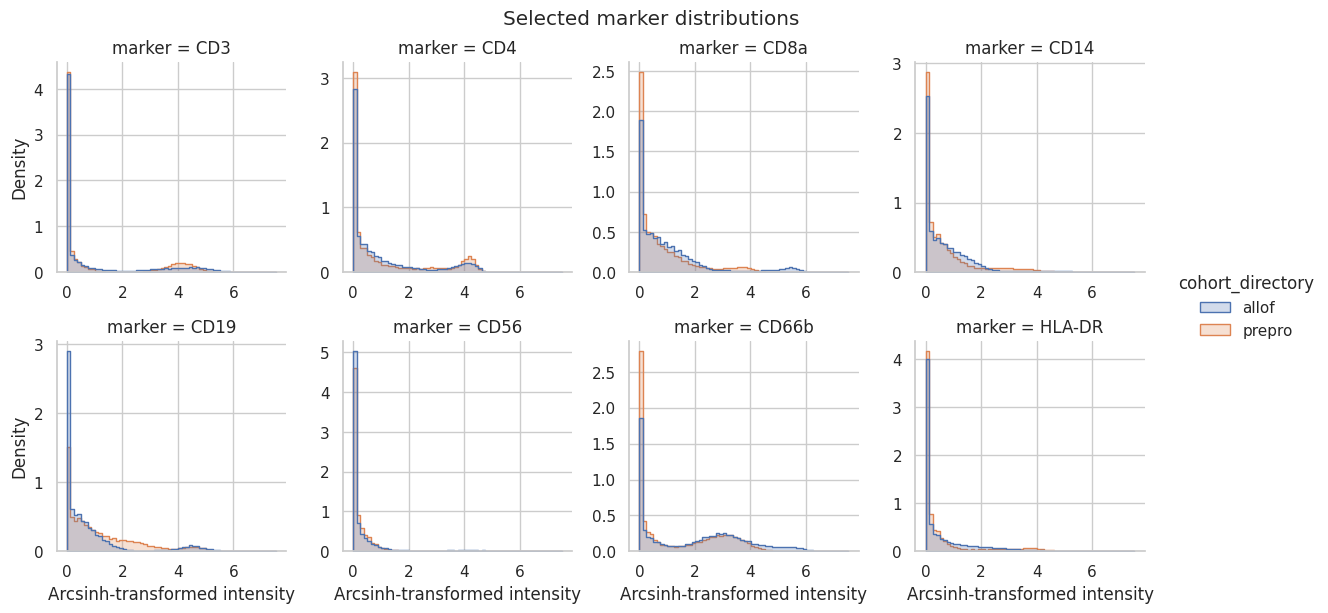

In [4]:
markers_to_plot = [
    marker
    for marker in ["CD3", "CD4", "CD8a", "CD14", "CD19", "CD56", "CD66b", "HLA-DR"]
    if marker in marker_names
]
distribution_data = sampled_cells.melt(
    id_vars=["cohort_directory", "sample_name", "cell_type"],
    value_vars=markers_to_plot,
    var_name="marker",
    value_name="arcsinh_intensity",
)

plot = sns.displot(
    data=distribution_data,
    x="arcsinh_intensity",
    hue="cohort_directory",
    col="marker",
    col_wrap=4,
    kind="hist",
    stat="density",
    common_norm=False,
    element="step",
    bins=60,
    height=3,
    facet_kws={"sharex": False, "sharey": False},
)
plot.set_axis_labels("Arcsinh-transformed intensity", "Density")
plot.fig.suptitle("Selected marker distributions", y=1.02)
plt.show()

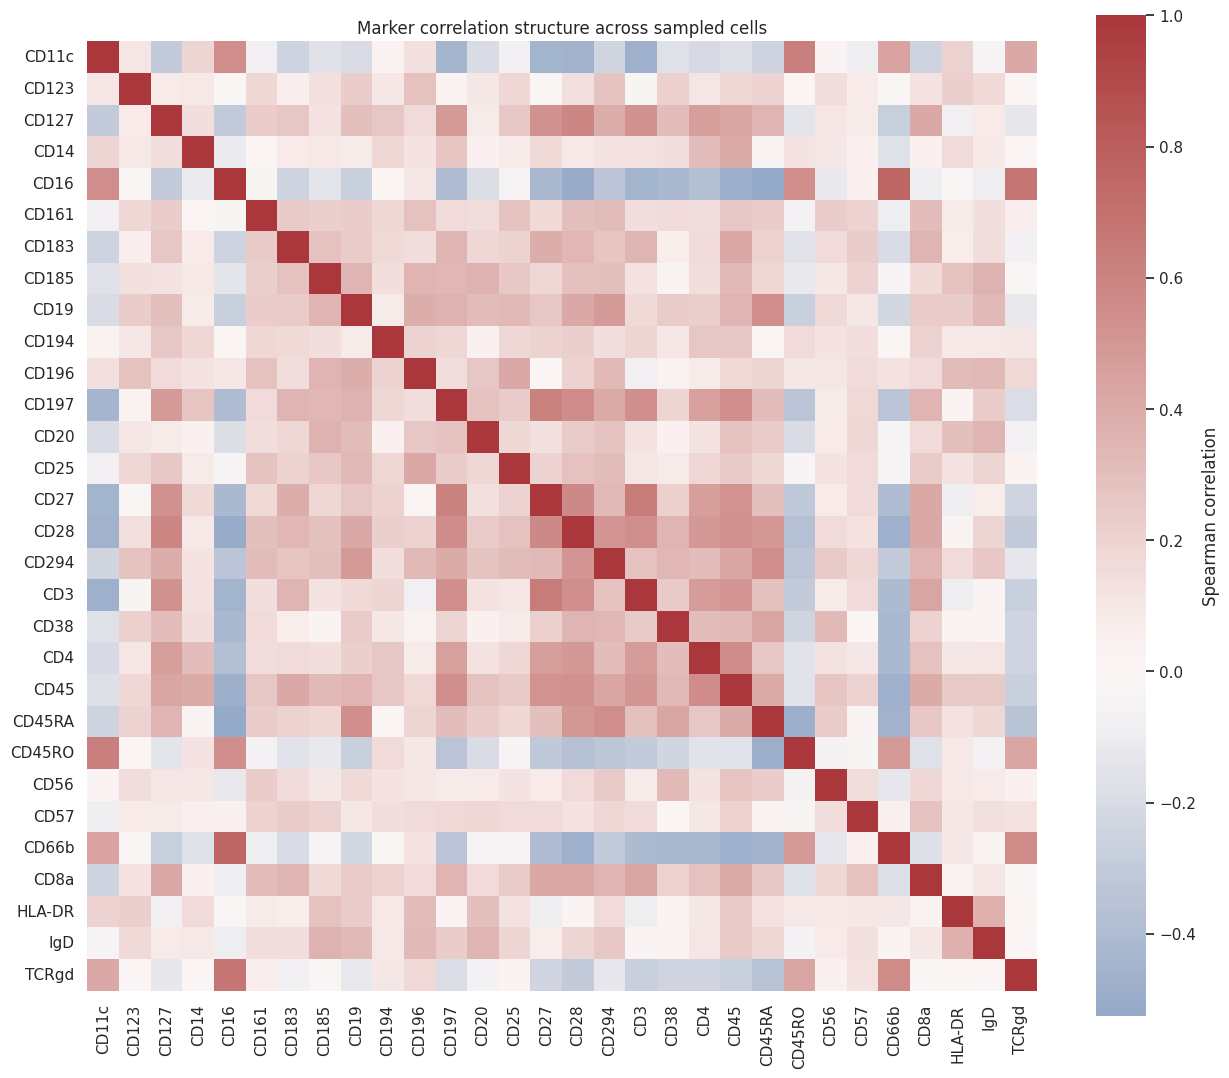

In [5]:
correlation_matrix = sampled_cells[marker_names].corr(method="spearman")

plt.figure(figsize=(13, 11))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    square=True,
    cbar_kws={"label": "Spearman correlation"},
)
plt.title("Marker correlation structure across sampled cells")
plt.tight_layout()
plt.show()

## 5. Gated population composition

Cell-type labels are auxiliary annotations and were not MAESTRO encoder inputs. They are useful here for confirming that the legacy snapshot contains the whole-blood granulocyte compartment.

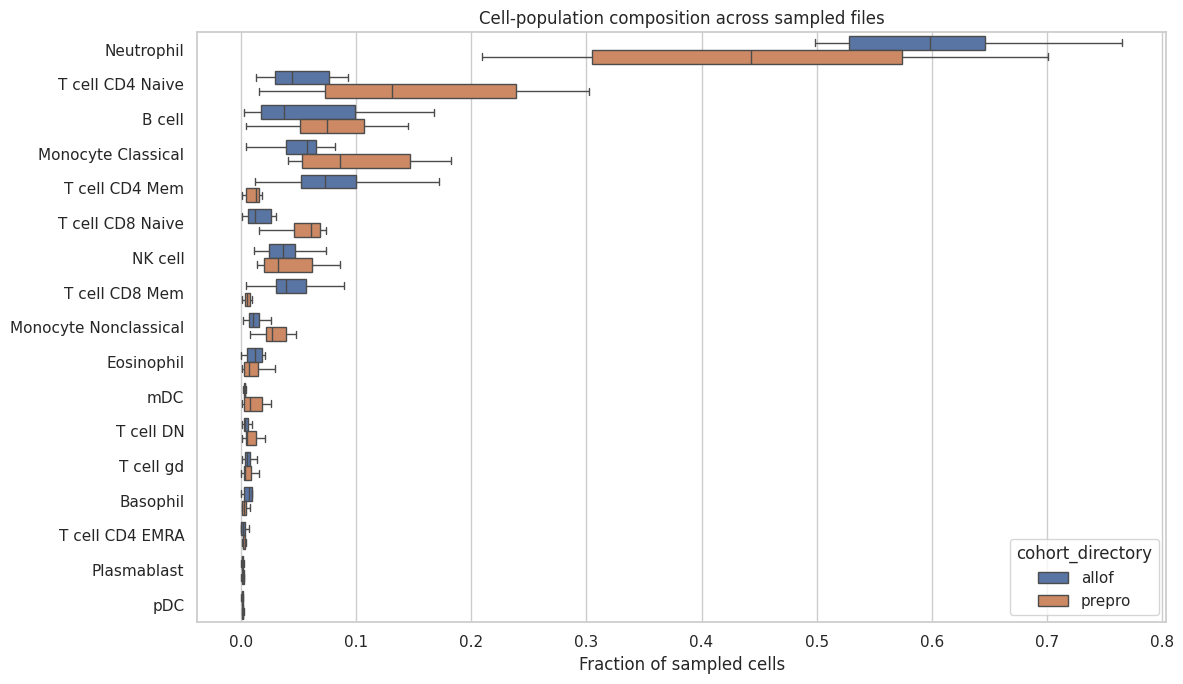

In [6]:
population_counts = (
    sampled_cells.groupby(
        ["cohort_directory", "sample_name", "cell_type"],
        observed=True,
    )
    .size()
    .rename("sampled_cells")
    .reset_index()
)
sampled_totals = population_counts.groupby(
    ["cohort_directory", "sample_name"], observed=True
)["sampled_cells"].transform("sum")
population_counts["sampled_fraction"] = (
    population_counts["sampled_cells"] / sampled_totals
)

population_order = (
    population_counts.groupby("cell_type", observed=True)["sampled_cells"]
    .sum()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=population_counts,
    y="cell_type",
    x="sampled_fraction",
    hue="cohort_directory",
    order=population_order,
    showfliers=False,
)
plt.xlabel("Fraction of sampled cells")
plt.ylabel("")
plt.title("Cell-population composition across sampled files")
plt.tight_layout()
plt.show()

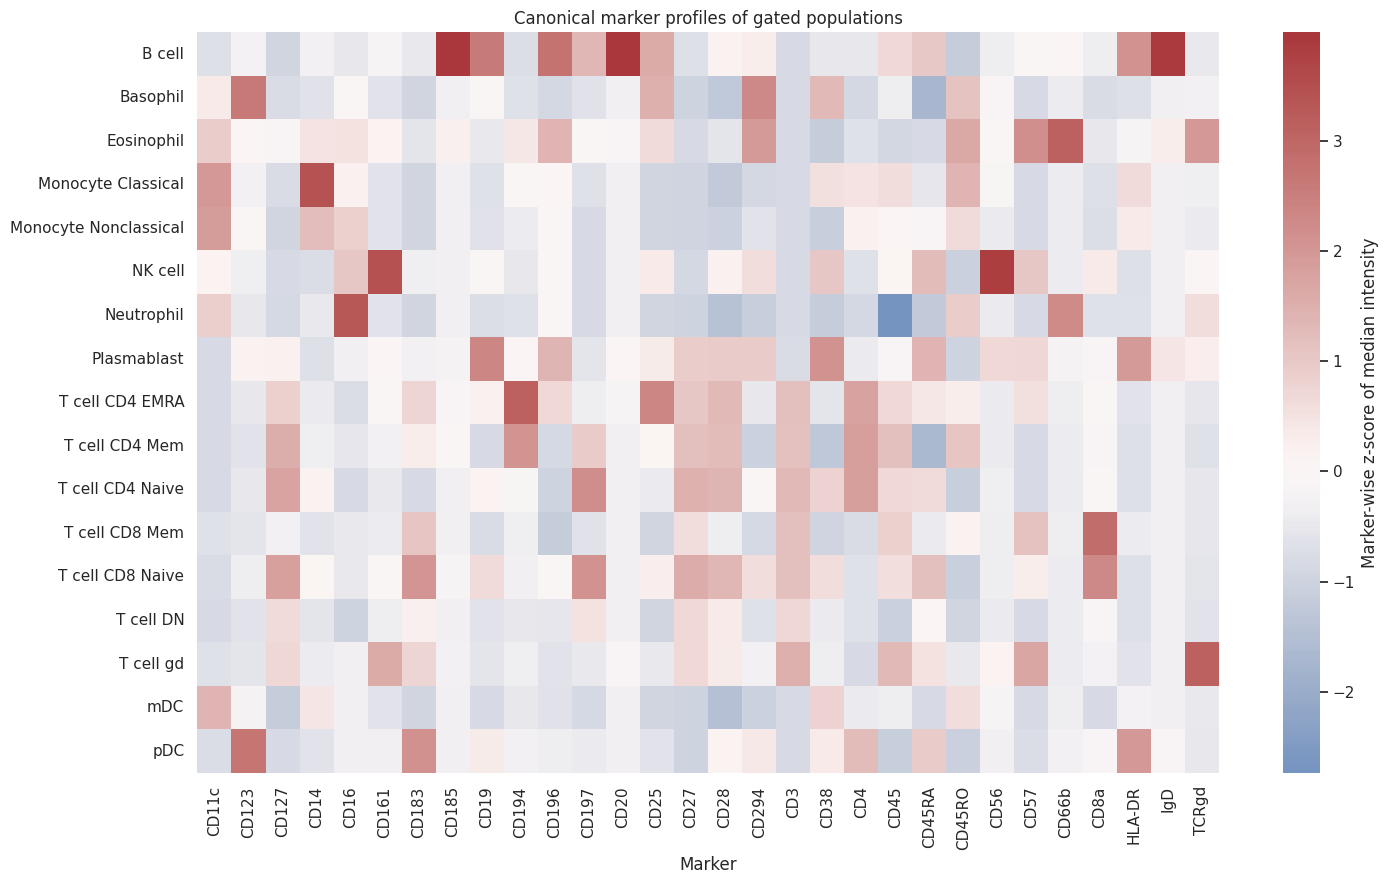

In [7]:
population_marker_medians = sampled_cells.groupby("cell_type", observed=True)[
    marker_names
].median()
population_marker_z_scores = population_marker_medians.apply(
    lambda values: (values - values.mean()) / values.std(ddof=0),
    axis=0,
).fillna(0)

plt.figure(figsize=(15, 9))
sns.heatmap(
    population_marker_z_scores,
    cmap="vlag",
    center=0,
    cbar_kws={"label": "Marker-wise z-score of median intensity"},
)
plt.title("Canonical marker profiles of gated populations")
plt.xlabel("Marker")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 6. PCA of sampled cells

This projection visualizes individual cells rather than MAESTRO sample embeddings.

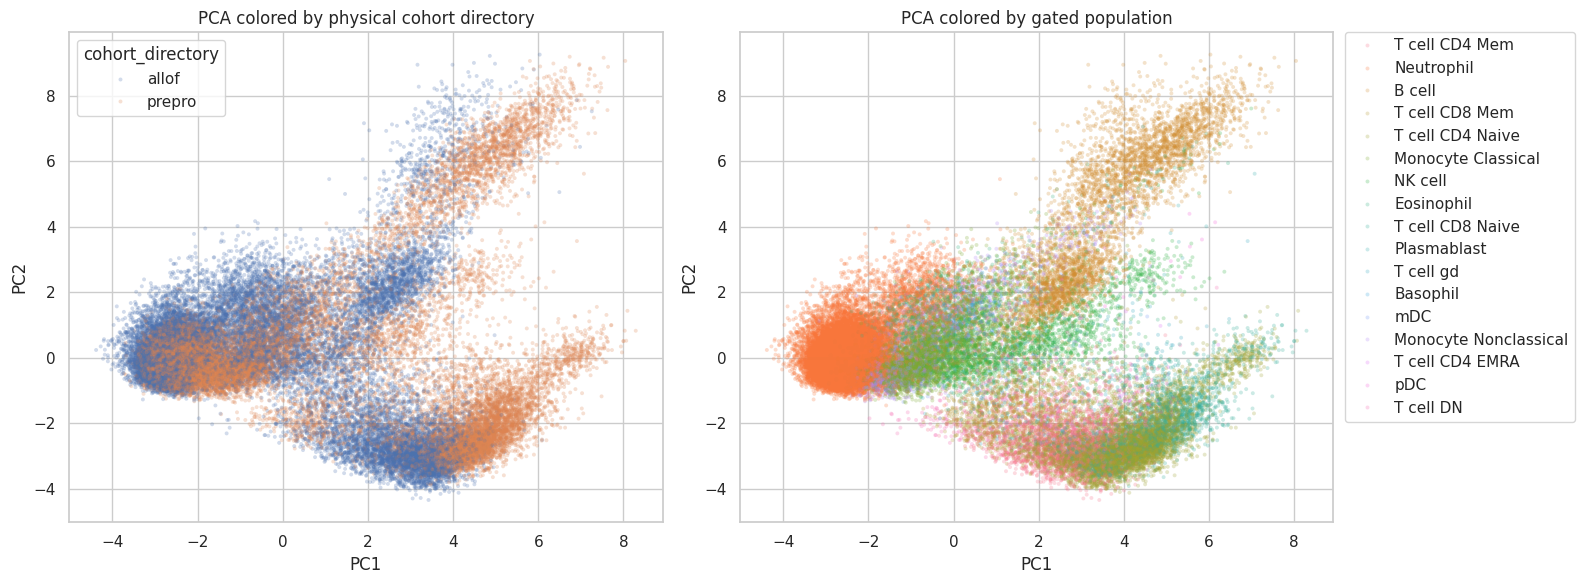

In [8]:
projection_indices = rng.choice(
    len(sampled_cells),
    size=min(MAXIMUM_PCA_CELLS, len(sampled_cells)),
    replace=False,
)
projection_cells = sampled_cells.iloc[projection_indices].reset_index(drop=True)
scaled_markers = StandardScaler().fit_transform(projection_cells[marker_names])
principal_components = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(
    scaled_markers
)
projection_cells["PC1"] = principal_components[:, 0]
projection_cells["PC2"] = principal_components[:, 1]

figure, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=projection_cells,
    x="PC1",
    y="PC2",
    hue="cohort_directory",
    alpha=0.25,
    s=8,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("PCA colored by physical cohort directory")

sns.scatterplot(
    data=projection_cells,
    x="PC1",
    y="PC2",
    hue="cell_type",
    alpha=0.25,
    s=8,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("PCA colored by gated population")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

## 7. Optional UMAP

Set `RUN_UMAP = True` in the first cell to run this slower projection.

/vast/projects/arjunraj/rohitproject/maestro/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/vast/projects/arjunraj/rohitproject/maestro/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


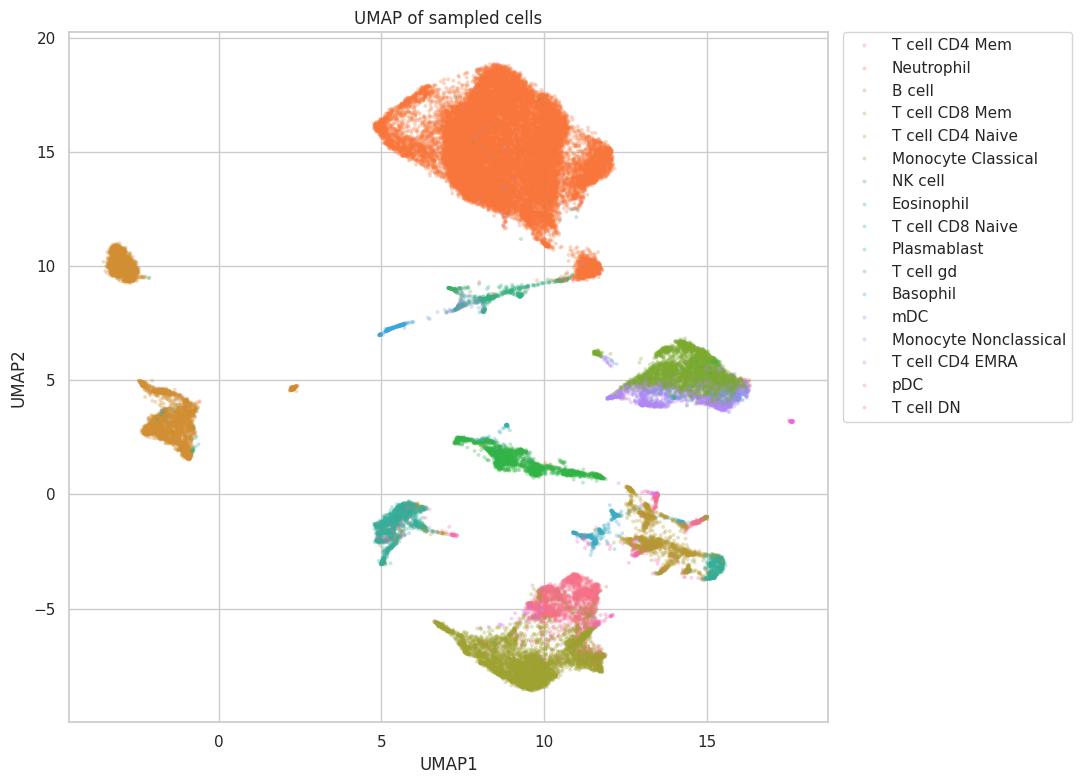

In [9]:
if RUN_UMAP:
    from umap import UMAP

    umap_coordinates = UMAP(
        n_neighbors=30,
        min_dist=0.2,
        metric="euclidean",
        random_state=RANDOM_SEED,
    ).fit_transform(scaled_markers)
    projection_cells["UMAP1"] = umap_coordinates[:, 0]
    projection_cells["UMAP2"] = umap_coordinates[:, 1]

    plt.figure(figsize=(11, 8))
    sns.scatterplot(
        data=projection_cells,
        x="UMAP1",
        y="UMAP2",
        hue="cell_type",
        alpha=0.3,
        s=8,
        linewidth=0,
    )
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.title("UMAP of sampled cells")
    plt.tight_layout()
    plt.show()
else:
    print("UMAP skipped. Set RUN_UMAP = True to enable it.")

## 8. Rare-population retention under cell subsampling

For a population with sample fraction $p$ and a random subsample of $M$ cells, the expected count is $Mp$ and the probability of retaining at least one cell is $1-(1-p)^M$.

In [10]:
SUBSAMPLE_SIZES = [5_000, 40_000, 100_000]
median_population_fractions = (
    population_counts.groupby("cell_type", observed=True)["sampled_fraction"]
    .median()
    .sort_values()
)

retention_rows = []
for cell_type, population_fraction in median_population_fractions.items():
    for subsample_size in SUBSAMPLE_SIZES:
        retention_rows.append(
            {
                "cell_type": cell_type,
                "median_sampled_fraction": population_fraction,
                "subsample_size": subsample_size,
                "expected_cells": subsample_size * population_fraction,
                "probability_at_least_one": 1
                - (1 - population_fraction) ** subsample_size,
            }
        )

retention_table = pd.DataFrame(retention_rows)
retention_table.pivot(
    index=["cell_type", "median_sampled_fraction"],
    columns="subsample_size",
    values="expected_cells",
).rename_axis(columns="Expected cells at subsample size")

,Expected cells at subsample size,5000,40000,100000
cell_type,median_sampled_fraction,,,
B cell,0.0562,281.0,2248.0,5620.0
Basophil,0.0032,16.0,128.0,320.0
Eosinophil,0.0089,44.5,356.0,890.0
Monocyte Classical,0.0610,305.0,2440.0,6100.0
Monocyte Nonclassical,0.0172,86.0,688.0,1720.0
NK cell,0.0359,179.5,1436.0,3590.0
Neutrophil,0.5535,2767.5,22140.0,55350.0
Plasmablast,0.0011,5.5,44.0,110.0
T cell CD4 EMRA,0.0017,8.5,68.0,170.0


## Interpretation checklist before training

- Confirm that all files share the same 30-marker panel using notebook 01.
- Decide whether to reproduce the paper's inclusion of low-quality samples or train a cleaner `QC == PASS` sensitivity model.
- Preserve whole-blood granulocytes for the closest approximation to the original MAESTRO corpus.
- Split longitudinal specimens by `patient_id`, never independently by file.
- Quantify how cell caps affect rare populations before changing the original sampling strategy.
- Freeze an explicit manifest because the available 1,870-file snapshot is not the paper's exact 1,792-file manifest.